# Ex.No.12 - Principal Component Analysis

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 15/04/2026_

In [59]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

In [43]:
# Load Dataset
df = pd.read_csv(r"D:\VI\FOML\Datasets\penguins.csv")
df = df.dropna()

print(df.shape)
df.head()

(332, 5)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181,3750,MALE
1,39.5,17.4,186,3800,FEMALE
2,40.3,18.0,195,3250,FEMALE
3,36.7,19.3,193,3450,FEMALE
4,39.3,20.6,190,3650,MALE


In [44]:
# Encode target column (sex)
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])

# Features and Target
X = df.drop("sex", axis=1)
y = df["sex"]

X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181,3750
1,39.5,17.4,186,3800
2,40.3,18.0,195,3250
3,36.7,19.3,193,3450
4,39.3,20.6,190,3650


In [45]:
# Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
# Apply PCA for dimensionality reduction (4D to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [47]:
# Variance ratio
print("Explained Variance Ratio :", pca.explained_variance_ratio_)
print("Total Variance Covered :", round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Explained Variance Ratio : [0.68713344 0.19641564]
Total Variance Covered : 88.35 %


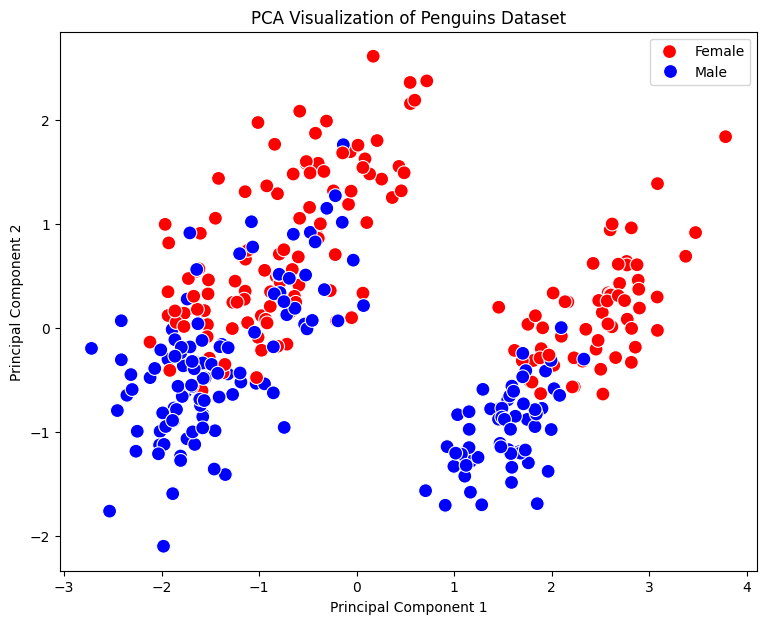

In [48]:
# Visualize PCA result
plt.figure(figsize=(9,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette={0:"blue", 1:"red"},
    s=100
)

plt.title("PCA Visualization of Penguins Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(labels=["Female", "Male"])
plt.show()

In [49]:
# Print the loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

loadings

,PC1,PC2
culmen_length_mm,0.453174,0.604990
culmen_depth_mm,-0.398518,0.792959
flipper_length_mm,0.576880,0.003798
body_mass_g,0.550478,0.072032


In [50]:
# Train KNN model on PCA data
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_pca, y)

KNeighborsClassifier()

In [81]:
# Create custom input data
custom_data = pd.DataFrame([{
    "culmen_length_mm": 45.2,
    "culmen_depth_mm": 17.1,
    "flipper_length_mm": 210,
    "body_mass_g": 4500
}])

# Scale and transform custom data using PCA
custom_scaled = scaler.transform(custom_data)
custom_pca = pca.transform(custom_scaled)

print("PC1 =", round(custom_pca[0][0], 3))
print("PC2 =", round(custom_pca[0][1], 3))

PC1 = 0.681
PC2 = 0.138


In [82]:
# Predict class of custom input
pred = knn_pca.predict(custom_pca)[0]

print("Predicted Class :", le.inverse_transform([pred])[0])

Predicted Class : MALE


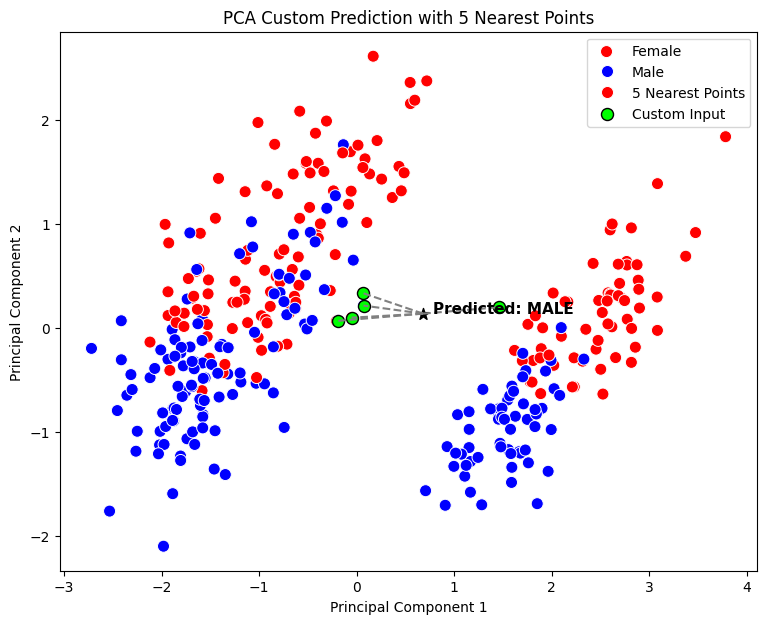

In [83]:
# Plot dataset with custom point and 5 nearest neighbors
# Find 5 nearest points in PCA space
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)

distances, indices = nn.kneighbors(custom_pca)

plt.figure(figsize=(9,7))

# Plot original PCA points
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette={0:"blue", 1:"red"},
    s=75
)

# Plot nearest neighbors
plt.scatter(
    X_pca[indices[0],0],
    X_pca[indices[0],1],
    c="lime",
    s=75,
    edgecolors="black",
    label="5 Nearest Points"
)

# Plot custom point
plt.scatter(
    custom_pca[:,0],
    custom_pca[:,1],
    c="black",
    marker="*",
    s=75,
    label="Custom Input"
)

# Draw lines from custom point to neighbors
for idx in indices[0]:
    plt.plot(
        [custom_pca[0,0], X_pca[idx,0]],
        [custom_pca[0,1], X_pca[idx,1]],
        '--',
        color='gray',
        linewidth=1.5
    )

# Predicted class text
plt.text(
    custom_pca[0][0] + 0.1,
    custom_pca[0][1],
    f"Predicted: {le.inverse_transform([pred])[0]}",
    fontsize=11,
    weight="bold"
)

plt.title("PCA Custom Prediction with 5 Nearest Points")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(labels=["Female", "Male", "5 Nearest Points", "Custom Input"])
plt.show()